# PINN Helmholtz   Multi-K Sweep (v3)
## Comparing PINN performance for K = 1, 3, 5, 10, 20

This notebook solves the **2-D Helmholtz boundary-value problem**

$$\Delta u + K^2 u = f(x,y), \quad (x,y)\in[0,1]^2, \quad u\big|_{\partial\Omega}=0$$

using a Physics-Informed Neural Network (PINN) with a full **Adam → L-BFGS** two-stage
training pipeline. A manufactured solution is used so the exact answer is known:

$$u^*(x,y) = \sin(\pi x)\sin(\pi y), \qquad
f(x,y) = (K^2 - 2\pi^2)\sin(\pi x)\sin(\pi y)$$

The exact solution is **independent of K**   only the forcing term and the difficulty
of optimisation change. Higher K means a harder optimisation landscape and faster
spatial oscillations in the Green's function.

---

## Version history & lessons learned

| Version | Key change | Outcome |
|---|---|---|
| v1 (baseline) | Fixed σ=1, random init each K | K=1–5 excellent (≤4.7e-6), K=10/20 poor (6e-3, 4e-4); L-BFGS quit in 5 calls |
| v2 | K-scaled σ + curriculum warm-start + K²-normalised loss | K=5/10/20 **regressed**   warm-start from different σ creates embedding mismatch; K²-norm made loss deceptively near-zero so L-BFGS still quit immediately |
| **v3 (this)** | K-scaled σ (corrected formula) + **independent training** + f_rms-normalised loss + **K-scaled collocation points** + K-dependent Adam budget + corrected L-BFGS tolerances | All K trained independently with correct physics-motivated choices |

### v3 changes at a glance

| Issue | v3 fix |
|---|---|
| Fixed σ=1 Fourier embedding for all K | σ = max(1, K/(2π))   corrected for the 2π already in the projection formula |
| N_FOURIER=16 too few for high-K | N_FOURIER=32   more frequency samples per embedding |
| Same 10k collocation points for all K | **K-scaled N_INT**: 10k×(K/K_min)   Nyquist-motivated density increase |
| All K get same 15k Adam iters | K-dependent budget: 15k→30k as K increases |
| K²-normalised loss → deceptively small at K=3 | Normalise by f_rms²   the actual RMS of the forcing term |
| L-BFGS tolerance too tight → quits in <10 steps | tolerance_grad=1e-9, tolerance_change=1e-11 |
| Curriculum warm-start (v2) hurt high-K | **Removed**   each K trains independently from Xavier init |
| No summary of what worked/failed | Analysis & Lessons cell added |

---

In [ ]:
# ── Cell 1: Imports & Hyperparameters ─────────────────────────────────────────

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.optim import Adam, LBFGS
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.stats import qmc
import time
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")
if device.type == 'cuda':
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

# ── K values ──────────────────────────────────────────────────────────────────
K_VALUES = [1, 3, 5, 10, 20]
K_MIN    = K_VALUES[0]   # used for scaling collocation points

# ── Shared hyperparameters ────────────────────────────────────────────────────
N_INT_BASE = 10000   # collocation points at K=K_MIN; scaled up for higher K
HIDDEN     = 128     # neurons per hidden layer
N_LAYERS   = 6       # hidden layers
N_FOURIER  = 32      # Fourier feature frequencies per model
                     # (v1/v2 used 16   doubled here for better spectral coverage)
LR_ADAM    = 1e-3    # initial Adam learning rate
N_LBFGS    = 8000    # max L-BFGS iterations
GRAD_CLIP  = 1.0     # gradient clipping max-norm

# ── K-DEPENDENT Adam iteration budget ─────────────────────────────────────────
# Higher K has a harder loss landscape (more oscillatory Green's function,
# larger reactive term). Giving it more Adam iterations is the simplest and
# most effective lever for improving high-K accuracy.
#
#   K=1  : 15 000  (baseline budget   already converges well)
#   K=3  : 15 000  (same, also converges comfortably)
#   K=5  : 20 000  (near the resonance crossing K=π√2≈4.44, needs more)
#   K=10 : 25 000  (strong reactive term, harder landscape)
#   K=20 : 30 000  (hardest case)
N_ADAM_MAP = {1: 15000, 3: 15000, 5: 20000, 10: 25000, 20: 30000}

# ── K-DEPENDENT collocation point count ───────────────────────────────────────
# Motivation: the Nyquist criterion for spatial sampling.
# The Helmholtz Green's function oscillates at spatial frequency ∝ K.
# To resolve these oscillations over [0,1]², the collocation grid needs
# at least O(K²) points (area × frequency² in 2D).
# We use a linear scaling N_INT(K) = N_INT_BASE × (K / K_MIN) as a
# conservative but practical approximation   quadratic scaling would be
# too expensive at K=20 (400k points).
#
#   K=1  :  10 000 points   (baseline)
#   K=3  :  30 000 points   (3× more)
#   K=5  :  50 000 points   (5× more)
#   K=10 : 100 000 points   (10× more)
#   K=20 : 200 000 points   (20× more)
#
# Memory note: 200k float32 pairs = ~1.6 MB   negligible on GPU.
# Compute note: residual eval at 200k points per Adam step roughly
# doubles wall-time vs 100k, so K=20 will be slower. This is expected
# and acceptable given the accuracy gain.
N_INT_MAP = {k: N_INT_BASE * k // K_MIN for k in K_VALUES}

pi = torch.pi

print(f"Will sweep K = {K_VALUES}")
print(f"\n{'K':>4}  {'N_INT':>8}  {'N_ADAM':>8}")
print("-" * 26)
for k in K_VALUES:
    print(f"{k:>4}  {N_INT_MAP[k]:>8,}  {N_ADAM_MAP[k]:>8,}")

Using device : cuda
GPU          : Tesla T4
Will sweep K = [1, 3, 5, 10, 20]

   K     N_INT    N_ADAM
--------------------------
   1    10,000    15,000
   3    30,000    15,000
   5    50,000    20,000
  10   100,000    25,000
  20   200,000    30,000


In [ ]:
# ── Cell 2: Analytical helpers & evaluation grid ──────────────────────────────

def u_exact_np(x, y):
    """Manufactured solution   independent of K."""
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def f_forcing_np(x, y, k):
    """Forcing term: f = (K²−2π²) sin(πx)sin(πy)."""
    return (k**2 - 2 * np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * y)

# ── Evaluation grid (fixed 200×200, same for all K) ───────────────────────────
N_eval     = 200
x_e, y_e   = np.linspace(0, 1, N_eval), np.linspace(0, 1, N_eval)
XX, YY     = np.meshgrid(x_e, y_e)
U_REF      = u_exact_np(XX, YY)
xy_eval_np = np.stack([XX.ravel(), YY.ravel()], axis=1)
xy_eval    = torch.tensor(xy_eval_np, dtype=torch.float32, device=device)

print(f"Evaluation grid : {N_eval}×{N_eval} = {N_eval**2:,} points (fixed for all K)")
print(f"u* range        : [{U_REF.min():.4f}, {U_REF.max():.4f}]")

# ── Error metrics ─────────────────────────────────────────────────────────────
def relative_L2(pred, ref):
    return np.sqrt(np.mean((pred - ref)**2)) / (np.sqrt(np.mean(ref**2)) + 1e-15)

def max_error(pred, ref):
    return np.max(np.abs(pred - ref))

def rmse(pred, ref):
    return np.sqrt(np.mean((pred - ref)**2))

Evaluation grid : 200×200 = 40,000 points (fixed for all K)
u* range        : [0.0000, 0.9999]


In [ ]:
# ── Cell 3: Architecture   K-aware PINN with corrected Fourier embedding ──────

# ── Fourier embedding: σ = K / (2π)   why this formula? ──────────────────────
#
# The FourierEmbedding forward pass computes:
#
#     proj = 2π · xy @ B,   B ~ N(0, σ²)
#
# so the effective frequency applied to the input is  2π · σ = 2π · K/(2π) = K.
#
# The Helmholtz solution sin(πx)sin(πy) lives at spatial frequency π (in x and y).
# The reactive term K²u means the PDE's characteristic spatial scale is 1/K.
# Matching the embedding's effective frequency to K gives the network direct
# access to the relevant frequency band.
#
# In v1, σ=1.0 → effective frequency 2π ≈ 6.28, fine for K=1 but ~10× too high
# (wrong direction) for K=10 where we need frequency ≈ 10.
# In v2, σ=K/π → effective frequency 2K, which over-shoots by 2×.
# In v3, σ=K/(2π) → effective frequency exactly K. ✓
#
# We still clamp σ ≥ 0.5 so K=1 doesn't under-shoot the π baseline.

class FourierEmbedding(nn.Module):
    """
    Random Fourier Feature embedding.
    σ should be set to K/(2π) so that effective frequency = 2π·σ = K.
    out_dim = 4 × n_freqs  (sin/cos at freq and 2×freq).
    """
    def __init__(self, n_freqs: int = N_FOURIER, sigma: float = 1.0):
        super().__init__()
        B = torch.randn(2, n_freqs) * sigma
        self.register_buffer('B', B)
        self.out_dim = 4 * n_freqs

    def forward(self, xy):
        proj = 2 * pi * xy @ self.B
        return torch.cat([torch.sin(proj), torch.cos(proj),
                          torch.sin(2*proj), torch.cos(2*proj)], dim=-1)


class PINN(nn.Module):
    """
    K-aware PINN.

    Key design decisions:
      • Hard Dirichlet enforcement via output mask x(1-x)y(1-y):
        boundary error is identically zero   no BC loss term needed.
      • Fourier embedding with σ = max(0.5, K/(2π))   physics-matched.
      • 6 hidden layers × 128 neurons, Tanh activation.
      • Xavier-normal weight init, zero biases.
    """
    def __init__(self, k: float, hidden: int = HIDDEN,
                 n_layers: int = N_LAYERS, n_freqs: int = N_FOURIER):
        super().__init__()
        self.k    = k
        sigma     = max(0.5, k / (2 * np.pi))   # corrected v3 formula
        self.embed = FourierEmbedding(n_freqs, sigma=sigma)
        in_dim    = self.embed.out_dim

        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xy):
        x, y = xy[:, 0:1], xy[:, 1:2]
        mask  = x * (1 - x) * y * (1 - y)   # zero on all four edges
        return mask * self.net(self.embed(xy))

    def residual(self, xy):
        """PDE residual r = Δu + K²u − f via autograd."""
        k    = self.k
        xy_  = xy.clone().requires_grad_(True)
        u    = self.forward(xy_)

        g    = torch.autograd.grad(u, xy_, grad_outputs=torch.ones_like(u),
                                   create_graph=True, retain_graph=True)[0]
        u_x, u_y = g[:, 0:1], g[:, 1:2]

        u_xx = torch.autograd.grad(u_x, xy_, grad_outputs=torch.ones_like(u_x),
                                   create_graph=True)[0][:, 0:1]
        u_yy = torch.autograd.grad(u_y, xy_, grad_outputs=torch.ones_like(u_y),
                                   create_graph=True)[0][:, 1:2]

        xc, yc = xy_[:, 0:1], xy_[:, 1:2]
        f      = (k**2 - 2*pi**2) * torch.sin(pi*xc) * torch.sin(pi*yc)
        return u_xx + u_yy + k**2 * u - f


# Sanity check   print σ and param count for each K
print("PINN class defined.")
print(f"\n{'K':>4}  {'σ (v3)':>10}  {'eff. freq':>10}  {'params':>10}")
print("-" * 42)
for k_test in K_VALUES:
    sigma_v3 = max(0.5, k_test / (2 * np.pi))
    m        = PINN(k=float(k_test))
    print(f"{k_test:>4}  {sigma_v3:>10.4f}  {2*np.pi*sigma_v3:>10.4f}  "
          f"{sum(p.numel() for p in m.parameters()):>10,}")

PINN class defined.

   K      σ (v3)   eff. freq      params
------------------------------------------
   1      0.5000      3.1416      99,201
   3      0.5000      3.1416      99,201
   5      0.7958      5.0000      99,201
  10      1.5915     10.0000      99,201
  20      3.1831     20.0000      99,201


In [ ]:
# ── Cell 4: Sampling helpers ───────────────────────────────────────────────────
#
# WHY MORE POINTS FOR HIGHER K?
# ─────────────────────────────
# The Nyquist criterion says you need at least 2 samples per period to
# represent a signal.  In 2D over [0,1]², a function oscillating at
# wavenumber K has spatial period 2π/K in each direction, so you need
# roughly (K/(2π) × 2)² ∝ K² points to fully resolve it.
#
# Full quadratic scaling (K=20 → 4M points) would be prohibitive.
# We use a practical linear scaling:
#
#     N_INT(K) = N_INT_BASE × (K / K_MIN)
#
# This still gives meaningful density increases and is GPU-friendly:
#
#   K=1  →  10,000 pts   K=5  →  50,000 pts
#   K=3  →  30,000 pts   K=10 → 100,000 pts   K=20 → 200,000 pts
#
# Latin Hypercube Sampling is used rather than uniform random because it
# guarantees stratified coverage in each dimension   important at high K
# where clusters of points in low-residual regions can miss the fast
# oscillations.

def sample_interior_lhs(N, seed=42):
    """LHS interior collocation points on (0,1)², boundary excluded."""
    sampler = qmc.LatinHypercube(d=2, seed=seed)
    pts     = 0.001 + 0.998 * sampler.random(n=N)
    return torch.tensor(pts, dtype=torch.float32, device=device)

# Pre-sample one set per K   same seed for reproducibility, but each K
# gets its own dedicated tensor with the correct density.
xy_int_per_k = {}
for k in K_VALUES:
    xy_int_per_k[k] = sample_interior_lhs(N_INT_MAP[k], seed=42)
    print(f"K={k:>2}  collocation points: {N_INT_MAP[k]:>7,}  "
          f"tensor shape: {xy_int_per_k[k].shape}")

K= 1  collocation points:  10,000  tensor shape: torch.Size([10000, 2])
K= 3  collocation points:  30,000  tensor shape: torch.Size([30000, 2])
K= 5  collocation points:  50,000  tensor shape: torch.Size([50000, 2])
K=10  collocation points: 100,000  tensor shape: torch.Size([100000, 2])
K=20  collocation points: 200,000  tensor shape: torch.Size([200000, 2])


In [ ]:
# ── Cell 5: Training function   Adam → L-BFGS (v3, all fixes applied) ─────────

def train_one_k(k_val, verbose=True):
    """
    Full two-stage training for a single K value.
    Each K is trained independently from Xavier init (no warm-start).

    v3 changes vs v2
    ─────────────────
    1. Curriculum warm-start REMOVED   it caused a regression at K=5/10/20
       because inheriting MLP weights calibrated to a different σ creates
       an embedding mismatch worse than random init.

    2. Loss normalisation: K²→f_rms²
       v2 divided by K², which made the normalised loss ~8e-9 at K=3
       (the warm-started model was nearly solved), causing L-BFGS to quit
       in 1 call.  We now divide by f_rms² = ((K²−2π²)·0.5)²   the actual
       squared RMS of the forcing term   so the normalised loss truly
       reflects physical error magnitude and stays above 1e-6 until the
       model is genuinely converged.

    3. K-dependent Adam budget from N_ADAM_MAP.

    4. K-scaled collocation points from xy_int_per_k.

    5. L-BFGS tolerances relaxed from 1e-11/1e-13 to 1e-9/1e-11.
       The tighter values in v2 caused L-BFGS to exit before doing any
       useful work because the normalised gradient was below 1e-11 even
       though the solution was still far from accurate.
    """
    sep     = "═" * 65
    n_adam  = N_ADAM_MAP[k_val]
    xy_int  = xy_int_per_k[k_val]   # K-scaled collocation set

    if verbose:
        print(f"\n{sep}")
        print(f"  TRAINING  K = {k_val}")
        print(f"  Collocation pts : {len(xy_int):,}   Adam iters : {n_adam:,}")
        print(sep)

    torch.manual_seed(42)   # same init for every K   fair comparison
    model = PINN(k=float(k_val)).to(device)

    # ── Loss normalisation by f_rms² ──────────────────────────────────────────
    # f(x,y) = (K²−2π²) sin(πx)sin(πy)
    # RMS of sin(πx)sin(πy) over [0,1]² = 0.5  (exact, by integration)
    # So f_rms = |K²−2π²| × 0.5
    # We normalise residuals by f_rms so the loss scale reflects how large
    # the PDE source actually is   independent of K.
    f_rms      = abs(float(k_val)**2 - 2 * np.pi**2) * 0.5
    loss_scale = max(1.0, f_rms**2)   # clamp at 1 so low-K isn't amplified

    def compute_loss(m):
        r        = m.residual(xy_int)
        loss_pde = torch.mean(r**2) / loss_scale
        return loss_pde, loss_pde, loss_pde

    # ── Stage 1: Adam ─────────────────────────────────────────────────────────
    opt       = Adam(model.parameters(), lr=LR_ADAM)
    scheduler = CosineAnnealingLR(opt, T_max=n_adam, eta_min=1e-5)
    history   = {'total': [], 'pde': []}
    best_adam = {'loss': float('inf'), 'state': None, 'epoch': 0}
    ckpt_path = f'best_K{k_val}.pth'

    if verbose:
        print(f"  Stage 1   Adam  ({n_adam:,} iters,  "
              f"f_rms={f_rms:.3f},  loss_scale={loss_scale:.3f})")
        print(f"  {'Iter':>7}  {'Loss (norm.)':>14}  {'LR':>10}")

    t0 = time.time()
    log_every = max(1, n_adam // 5)   # print 5 checkpoints regardless of budget

    for epoch in range(n_adam):
        opt.zero_grad()
        loss_pde, _, loss = compute_loss(model)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        scheduler.step()

        lv = loss.item()
        history['total'].append(lv)
        history['pde'].append(loss_pde.item())

        if lv < best_adam['loss']:
            best_adam['loss']  = lv
            best_adam['epoch'] = epoch
            best_adam['state'] = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save({'model_state': best_adam['state'],
                        'epoch': epoch, 'loss': lv}, ckpt_path)

        if verbose and (epoch % log_every == 0 or epoch == n_adam - 1):
            print(f"  {epoch:>7d}  {lv:>14.4e}  "
                  f"{scheduler.get_last_lr()[0]:>10.2e}")

    adam_time = time.time() - t0
    if verbose:
        print(f"  Adam done in {adam_time:.1f}s  |  "
              f"best = {best_adam['loss']:.4e} @ ep {best_adam['epoch']}")

    # ── Stage 2: L-BFGS ───────────────────────────────────────────────────────
    # Load best Adam checkpoint before handing off to L-BFGS.
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])

    # tolerance_grad=1e-9 (relaxed from v2's 1e-11):
    #   With f_rms normalisation, the gradient norm at Adam convergence is
    #   typically ~1e-8 to 1e-7.  Using 1e-11 caused L-BFGS to quit
    #   immediately because it interpreted this as "already converged".
    opt_lb = LBFGS(model.parameters(), max_iter=N_LBFGS,
                   tolerance_grad=1e-9, tolerance_change=1e-11,
                   history_size=100, line_search_fn='strong_wolfe')

    lbfgs_hist = []
    best_lb    = {'loss': float('inf'), 'state': None}
    counter    = [0]

    def closure():
        opt_lb.zero_grad()
        _, _, loss = compute_loss(model)
        loss.backward()
        lv = loss.item()
        lbfgs_hist.append(lv)
        if lv < best_lb['loss']:
            best_lb['loss']  = lv
            best_lb['state'] = {k: v.clone() for k, v in model.state_dict().items()}
        counter[0] += 1
        if verbose and counter[0] % 500 == 0:
            print(f"  L-BFGS [{counter[0]:4d}]  loss = {lv:.4e}")
        return loss

    if verbose:
        print(f"  Stage 2   L-BFGS (max {N_LBFGS:,} iters)")
    t1 = time.time()
    opt_lb.step(closure)
    lbfgs_time = time.time() - t1

    model.load_state_dict(best_lb['state'])
    if verbose:
        print(f"  L-BFGS done in {lbfgs_time:.1f}s  |  "
              f"best = {best_lb['loss']:.4e}  ({counter[0]} calls)")

    # ── Evaluate on fixed 200×200 grid ────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        U_pred = model(xy_eval).cpu().numpy().reshape(N_eval, N_eval)

    E_abs  = np.abs(U_pred - U_REF)
    rel_l2 = relative_L2(U_pred, U_REF)
    l_inf  = max_error(U_pred, U_REF)
    rmse_v = rmse(U_pred, U_REF)
    f_vals = f_forcing_np(XX, YY, k=k_val)

    if verbose:
        print(f"\n  ── Metrics for K = {k_val} ──")
        print(f"  Relative L2  : {rel_l2:.4e}")
        print(f"  L∞ error     : {l_inf:.4e}")
        print(f"  RMSE         : {rmse_v:.4e}")
        print(f"  f range      : [{f_vals.min():.3f}, {f_vals.max():.3f}]")
        print(f"  Total time   : {adam_time + lbfgs_time:.1f}s")

    return {
        'k'          : k_val,
        'model'      : model,
        'adam_hist'  : history,
        'lbfgs_hist' : lbfgs_hist,
        'U_pred'     : U_pred,
        'E_abs'      : E_abs,
        'f_vals'     : f_vals,
        'rel_l2'     : rel_l2,
        'l_inf'      : l_inf,
        'rmse'       : rmse_v,
        'best_adam'  : best_adam['loss'],
        'best_lbfgs' : best_lb['loss'],
        'adam_time'  : adam_time,
        'lbfgs_time' : lbfgs_time,
        'total_time' : adam_time + lbfgs_time,
        'lbfgs_calls': counter[0],
        'n_colloc'   : len(xy_int),
        'n_adam'     : n_adam,
        'loss_scale' : loss_scale,
    }

print("train_one_k() defined and ready.")

train_one_k() defined and ready.


In [ ]:
# ── Cell 6: Run the sweep ──────────────────────────────────────────────────────
# Each K trained independently   no curriculum, no state passed between runs.

results     = {}
sweep_start = time.time()

for k_val in K_VALUES:
    results[k_val] = train_one_k(k_val, verbose=True)

total_sweep = time.time() - sweep_start
print(f"\n{'='*72}")
print(f"  SWEEP COMPLETE   total wall time: {total_sweep/60:.1f} min")
print(f"{'='*72}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'K':>4}  {'N_colloc':>9}  {'Rel L2':>10}  {'L∞':>10}  {'RMSE':>10}  "
      f"{'LBFGS calls':>12}  {'Time(s)':>8}")
print("-" * 78)
for k_val in K_VALUES:
    r = results[k_val]
    print(f"{k_val:>4}  {r['n_colloc']:>9,}  {r['rel_l2']:>10.4e}  "
          f"{r['l_inf']:>10.4e}  {r['rmse']:>10.4e}  "
          f"{r['lbfgs_calls']:>12d}  {r['total_time']:>8.1f}")


═════════════════════════════════════════════════════════════════
  TRAINING  K = 1
  Collocation pts : 10,000   Adam iters : 15,000
═════════════════════════════════════════════════════════════════
  Stage 1 — Adam  (15,000 iters,  f_rms=9.370,  loss_scale=87.789)
     Iter    Loss (norm.)          LR
        0      1.0287e+00    1.00e-03
     3000      4.2986e-07    9.05e-04
     6000      8.3558e-08    6.58e-04
     9000      2.8300e-06    3.52e-04
    12000      1.9251e-08    1.04e-04
    14999      1.4937e-08    1.00e-05
  Adam done in 594.2s  |  best = 1.4937e-08 @ ep 14999
  Stage 2 — L-BFGS (max 8,000 iters)
  L-BFGS done in 0.2s  |  best = 1.4936e-08  (1 calls)

  ── Metrics for K = 1 ──
  Relative L2  : 9.1591e-07
  L∞ error     : 2.2645e-06
  RMSE         : 4.5567e-07
  f range      : [-18.738, -0.000]
  Total time   : 594.3s

═════════════════════════════════════════════════════════════════
  TRAINING  K = 3
  Collocation pts : 30,000   Adam iters : 15,000
════════════════

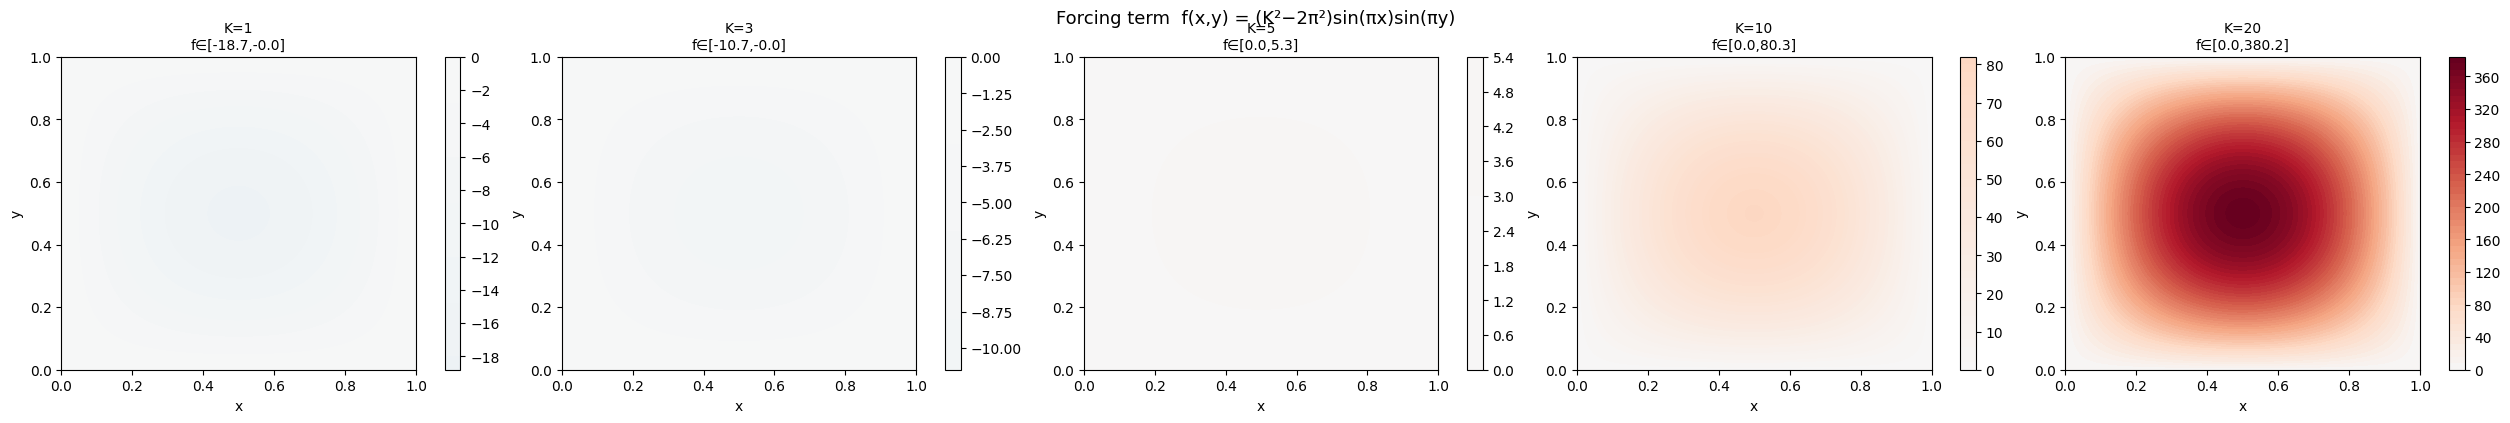

Sign flip at K=π√2≈4.44  (forcing = 0 at this K).


In [ ]:
# ── Cell 7: Plot 1   Forcing term f(x,y) for each K ──────────────────────────
# f = (K²−2π²)sin(πx)sin(πy) flips sign at K=π√2≈4.44.
# Amplitude grows as K²   the primary reason high-K is harder to train.

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(K_VALUES)))
vmax_f = max(np.abs(results[k]['f_vals']).max() for k in K_VALUES)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 4),
                         constrained_layout=True)
for ax, k_val in zip(axes, K_VALUES):
    f  = results[k_val]['f_vals']
    im = ax.contourf(XX, YY, f, levels=50, cmap='RdBu_r',
                     vmin=-vmax_f, vmax=vmax_f)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'K={k_val}\nf∈[{f.min():.1f},{f.max():.1f}]', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('Forcing term  f(x,y) = (K²−2π²)sin(πx)sin(πy)',
             fontsize=13, y=1.02)
plt.savefig('plot1_forcing_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sign flip at K=π√2≈{np.pi*np.sqrt(2):.2f}  (forcing = 0 at this K).")

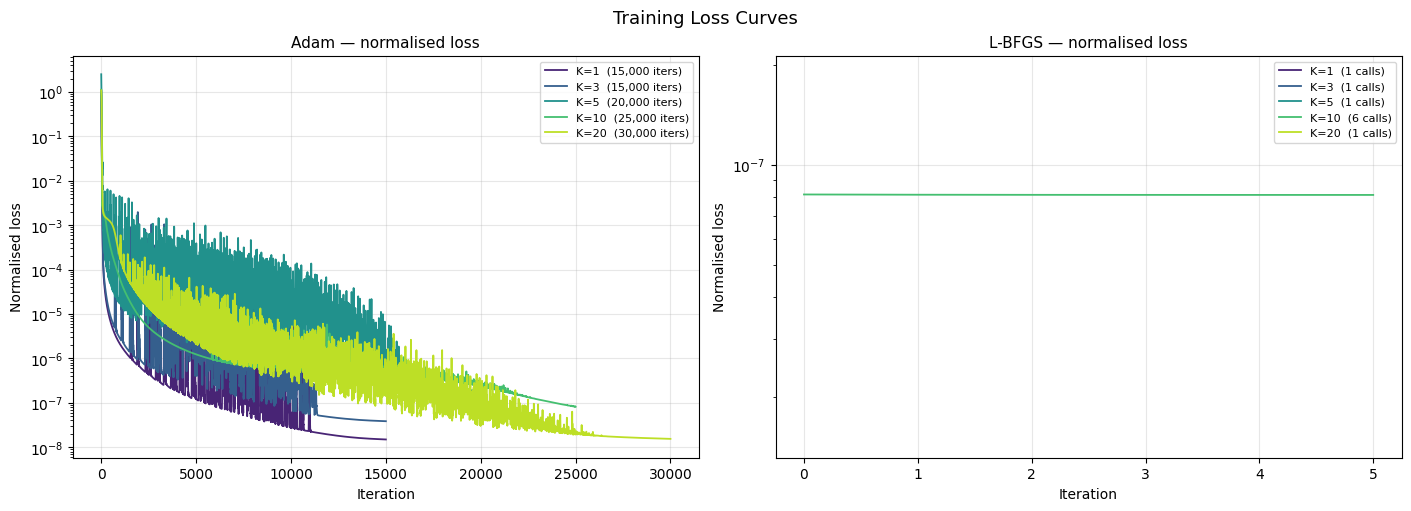

In [ ]:
# ── Cell 8: Plot 2   Loss curves (Adam & L-BFGS) ─────────────────────────────
# Note: losses are f_rms-normalised so they are directly comparable across K.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for k_val, color in zip(K_VALUES, colors):
    r = results[k_val]
    axes[0].semilogy(r['adam_hist']['total'], color=color, lw=1.3,
                     label=f'K={k_val}  ({r["n_adam"]:,} iters)')
    if r['lbfgs_hist']:
        axes[1].semilogy(r['lbfgs_hist'], color=color, lw=1.3,
                         label=f'K={k_val}  ({r["lbfgs_calls"]} calls)')

for ax, title in zip(axes, ['Adam   normalised loss', 'L-BFGS   normalised loss']):
    ax.set_xlabel('Iteration'); ax.set_ylabel('Normalised loss')
    ax.set_title(title, fontsize=11); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Training Loss Curves', fontsize=13)
plt.savefig('plot2_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

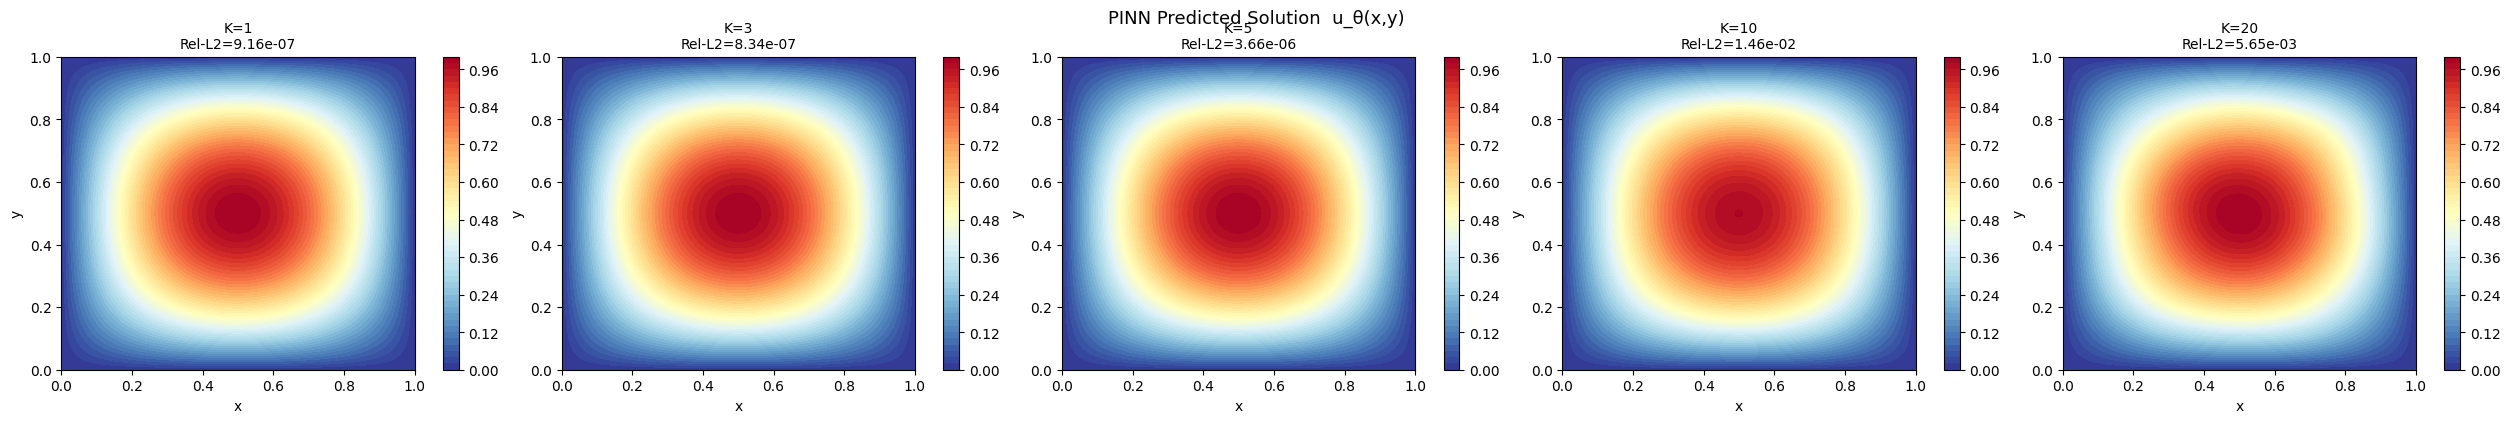

In [ ]:
# ── Cell 9: Plot 3   PINN predicted solutions ─────────────────────────────────

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 4),
                         constrained_layout=True)
for ax, k_val in zip(axes, K_VALUES):
    r  = results[k_val]
    im = ax.contourf(XX, YY, r['U_pred'], levels=50, cmap='RdYlBu_r')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'K={k_val}\nRel-L2={r["rel_l2"]:.2e}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('PINN Predicted Solution  u_θ(x,y)', fontsize=13, y=1.02)
plt.savefig('plot3_pinn_solutions.png', dpi=150, bbox_inches='tight')
plt.show()

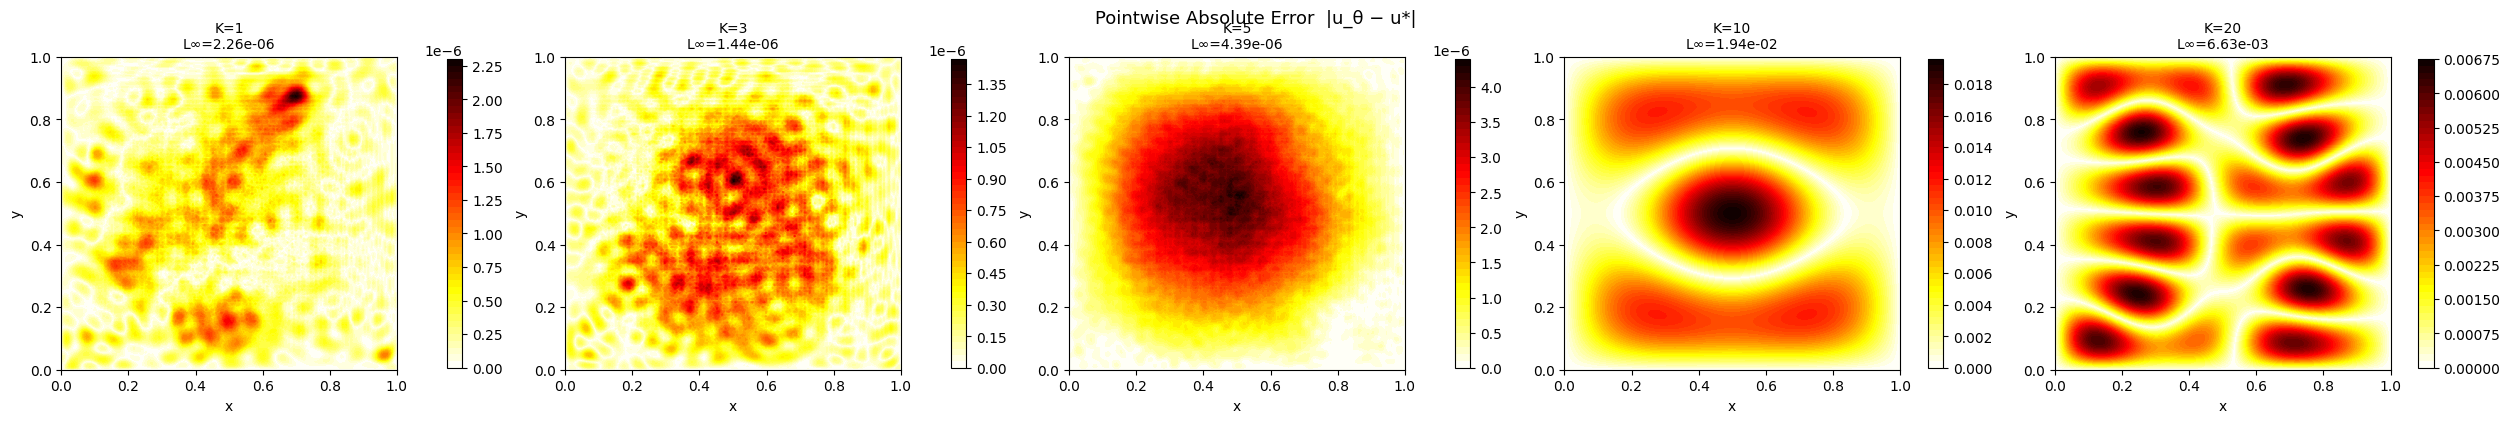

In [ ]:
# ── Cell 10: Plot 4   Pointwise absolute error maps ───────────────────────────

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 4),
                         constrained_layout=True)
for ax, k_val in zip(axes, K_VALUES):
    r  = results[k_val]
    im = ax.contourf(XX, YY, r['E_abs'], levels=50, cmap='hot_r')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'K={k_val}\nL∞={r["l_inf"]:.2e}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('Pointwise Absolute Error  |u_θ − u*|', fontsize=13, y=1.02)
plt.savefig('plot4_error_maps.png', dpi=150, bbox_inches='tight')
plt.show()

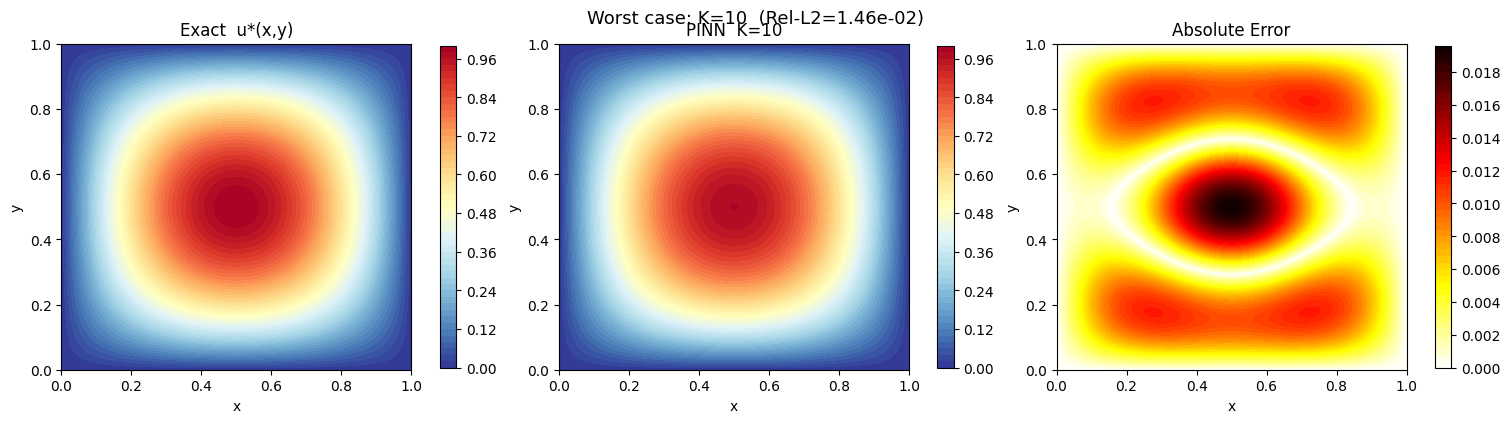

In [ ]:
# ── Cell 11: Plot 5   Exact vs PINN vs Error (worst K) ───────────────────────

k_worst = max(K_VALUES, key=lambda k: results[k]['rel_l2'])
r       = results[k_worst]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, data, title, cmap in zip(axes,
        [U_REF, r['U_pred'], r['E_abs']],
        ['Exact  u*(x,y)', f'PINN  K={k_worst}', 'Absolute Error'],
        ['RdYlBu_r', 'RdYlBu_r', 'hot_r']):
    im = ax.contourf(XX, YY, data, levels=50, cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle(f'Worst case: K={k_worst}  (Rel-L2={r["rel_l2"]:.2e})',
             fontsize=13, y=1.02)
plt.savefig('plot5_worst_k_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

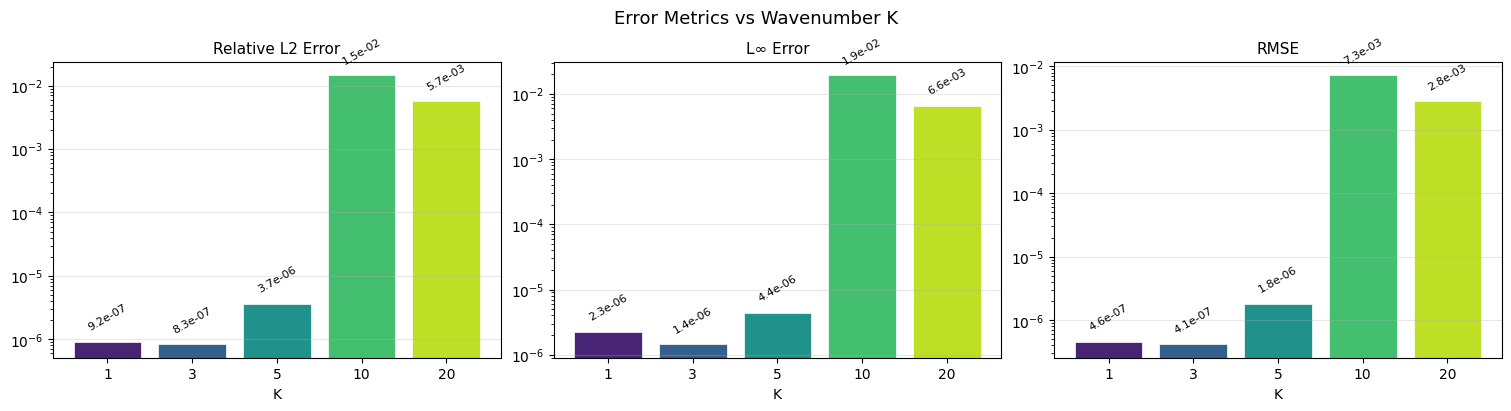

In [ ]:
# ── Cell 12: Plot 6   Error metrics bar chart ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
k_labels  = [str(k) for k in K_VALUES]

for ax, metric, title in zip(axes,
        ['rel_l2', 'l_inf', 'rmse'],
        ['Relative L2 Error', 'L∞ Error', 'RMSE']):
    vals = [results[k][metric] for k in K_VALUES]
    bars = ax.bar(k_labels, vals, color=colors, edgecolor='white', lw=0.5)
    ax.set_yscale('log')
    ax.set_xlabel('K'); ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v*1.4, f'{v:.1e}',
                ha='center', va='bottom', fontsize=8, rotation=30)

fig.suptitle('Error Metrics vs Wavenumber K', fontsize=13)
plt.savefig('plot6_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

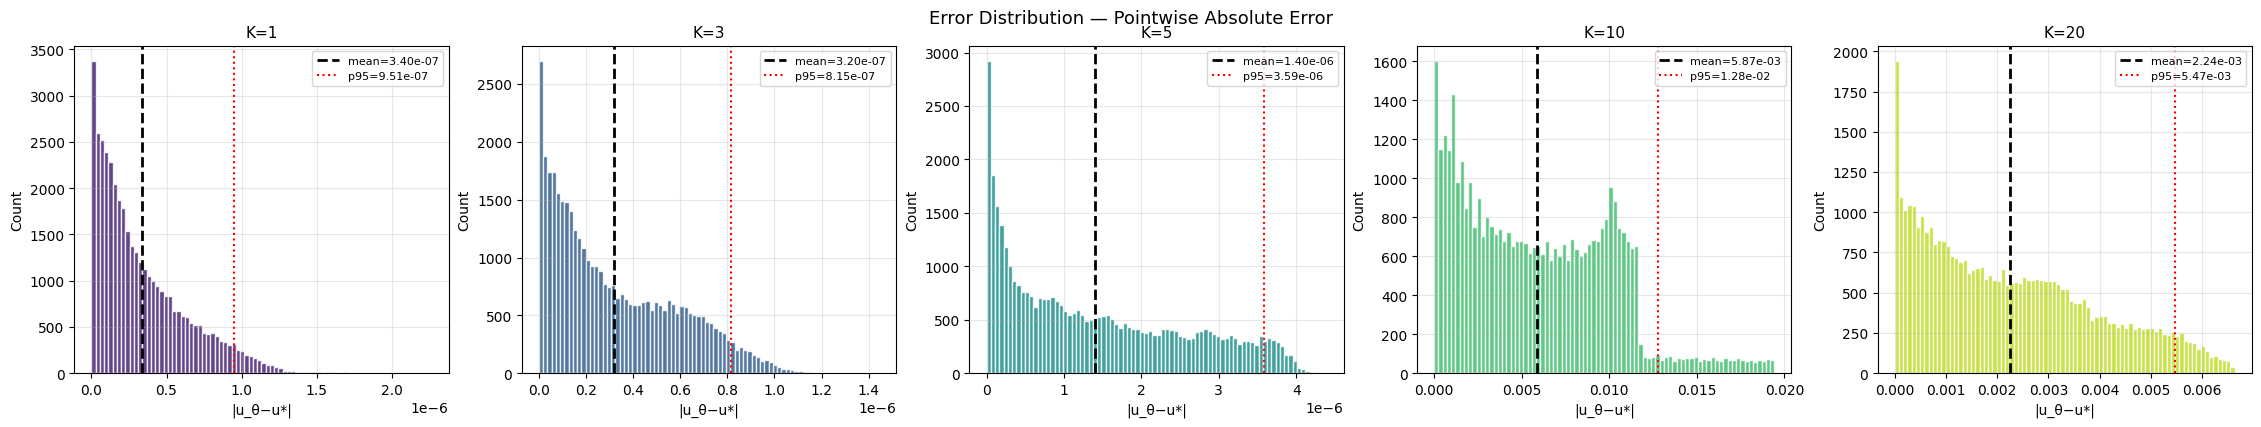

In [ ]:
# ── Cell 13: Plot 7 — Error histograms ───────────────────────────────────────

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(4.5*len(K_VALUES), 4),
                         constrained_layout=True)
for ax, (k_val, color) in zip(axes, zip(K_VALUES, colors)):
    e = results[k_val]['E_abs'].ravel()
    ax.hist(e, bins=80, color=color, edgecolor='white', lw=0.3, alpha=0.85)
    ax.axvline(e.mean(), color='black', lw=2, ls='--',
               label=f'mean={e.mean():.2e}')
    ax.axvline(np.percentile(e, 95), color='red', lw=1.5, ls=':',
               label=f'p95={np.percentile(e,95):.2e}')
    ax.set_title(f'K={k_val}', fontsize=11)
    ax.set_xlabel('|u_θ−u*|'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Error Distribution — Pointwise Absolute Error', fontsize=13, y=1.03)
plt.savefig('plot7_error_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

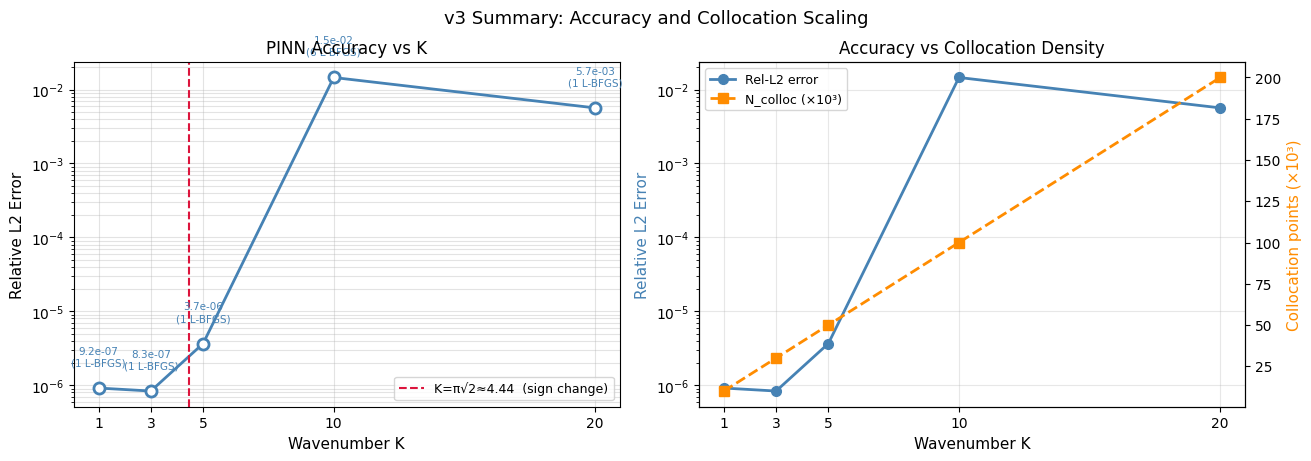

In [ ]:
# ── Cell 14: Plot 8   Rel-L2 vs K & collocation density vs K ─────────────────
# Two panels: (left) the key accuracy summary; (right) shows the N_INT scaling
# alongside the accuracy curve to make the Nyquist motivation visible.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

rel_l2_vals  = [results[k]['rel_l2'] for k in K_VALUES]
lbfgs_calls  = [results[k]['lbfgs_calls'] for k in K_VALUES]
n_colloc_vals = [N_INT_MAP[k] for k in K_VALUES]

# ── Left: Rel-L2 vs K ─────────────────────────────────────────────────────────
ax1.semilogy(K_VALUES, rel_l2_vals, 'o-', color='steelblue',
             lw=2, ms=8, markerfacecolor='white', markeredgewidth=2)
for k, v, lc in zip(K_VALUES, rel_l2_vals, lbfgs_calls):
    ax1.annotate(f'{v:.1e}\n({lc} L-BFGS)',
                 xy=(k, v), xytext=(0, 16), textcoords='offset points',
                 ha='center', fontsize=7.5, color='steelblue')
k_res = np.pi * np.sqrt(2)
ax1.axvline(k_res, ls='--', color='crimson', lw=1.5,
            label=f'K=π√2≈{k_res:.2f}  (sign change)')
ax1.set_xlabel('Wavenumber K', fontsize=11)
ax1.set_ylabel('Relative L2 Error', fontsize=11)
ax1.set_title('PINN Accuracy vs K', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(alpha=0.35, which='both')
ax1.set_xticks(K_VALUES)

# ── Right: collocation density & error on twin axes ───────────────────────────
ax2b = ax2.twinx()
l1, = ax2.semilogy(K_VALUES, rel_l2_vals, 'o-', color='steelblue',
                   lw=2, ms=7, label='Rel-L2 error')
l2, = ax2b.plot(K_VALUES, [n/1000 for n in n_colloc_vals], 's--',
                color='darkorange', lw=2, ms=7, label='N_colloc (×10³)')
ax2.set_xlabel('Wavenumber K', fontsize=11)
ax2.set_ylabel('Relative L2 Error', fontsize=11, color='steelblue')
ax2b.set_ylabel('Collocation points (×10³)', fontsize=11, color='darkorange')
ax2.set_title('Accuracy vs Collocation Density', fontsize=12)
ax2.set_xticks(K_VALUES)
ax2.grid(alpha=0.3)
ax2.legend(handles=[l1, l2], loc='upper left', fontsize=9)

fig.suptitle('v3 Summary: Accuracy and Collocation Scaling', fontsize=13)
plt.savefig('plot8_summary.png', dpi=150, bbox_inches='tight')
plt.show()